# Hafta 10 - Cats vs Dogs: CNN Siniflandirma

Bu notebook, `hafta10/archive/cats_set` ve `hafta10/archive/dogs_set` klasorlerindeki goruntuleri kullanarak bir CNN modeli ile siniflandirma yapar.

Akis:
- goruntuleri tanima ve ornekleme,
- train / validation / test ayirmasi,
- veri zenginlestirme (augmentation),
- PyTorch ile CNN egitimi,
- kayip ve basari grafikleri,
- karisiklik matrisi ve ornek tahminler.

Kurulum notu:
Bu proje uv ile yonetilen `.venv` ortaminda calisiyor. Gerekli paketler yoksa su komutlar kullanilir:
```bash
uv venv
uv pip install numpy matplotlib seaborn pillow scikit-learn torch torchvision
```

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42
BATCH_SIZE = 32
EPOCHS = 8
IMAGE_SIZE = 96

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("hafta10/archive")
base_dataset = datasets.ImageFolder(DATA_DIR)
class_names = base_dataset.classes

print(f"Classes: {class_names}")
print(f"Total images: {len(base_dataset)}")
print(f"Device: {device}")

Classes: ['cats_set', 'dogs_set']
Total images: 1000
Device: cuda


Train size: 800
Validation size: 100
Test size: 100


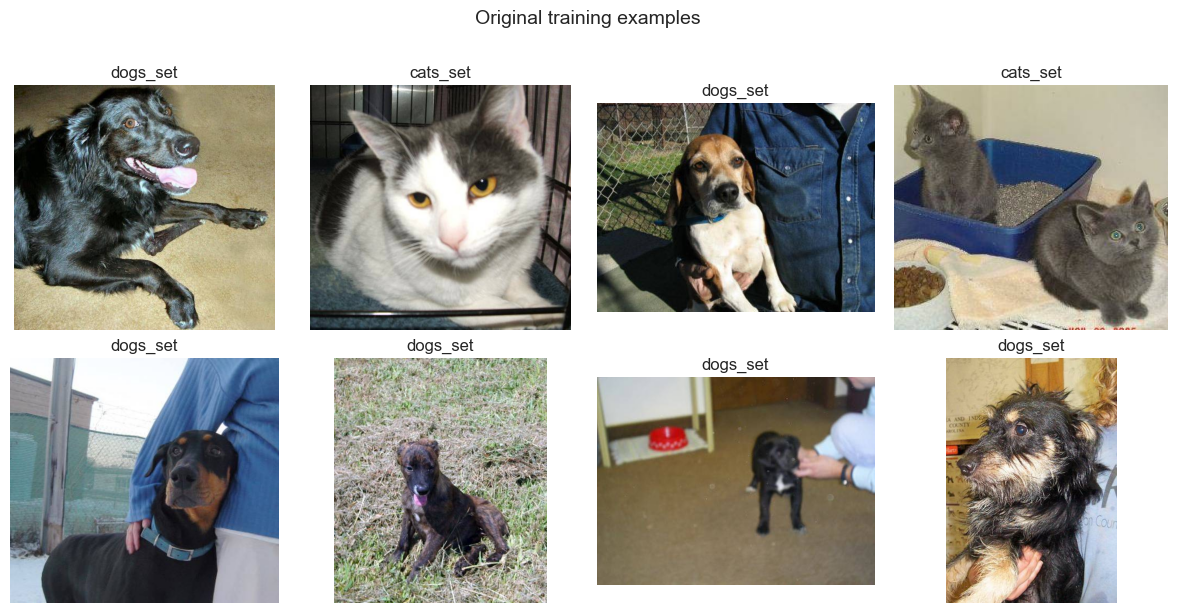

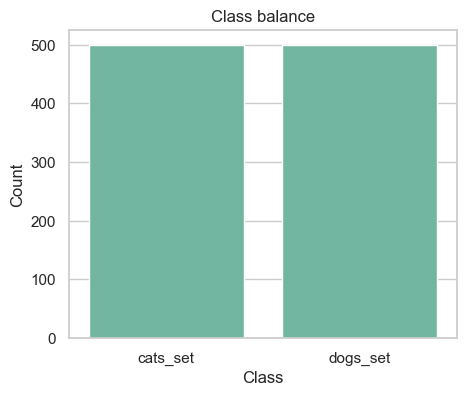

In [2]:
labels = np.array([label for _, label in base_dataset.samples])
indices = np.arange(len(base_dataset))
train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE, stratify=labels
)
temp_labels = labels[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=RANDOM_STATE, stratify=temp_labels
)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
eval_dataset = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(Subset(eval_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(Subset(eval_dataset, test_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print(f"Train size: {len(train_idx)}")
print(f"Validation size: {len(val_idx)}")
print(f"Test size: {len(test_idx)}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.ravel(), train_idx[:8]):
    image, label = base_dataset[idx]
    ax.imshow(image)
    ax.set_title(class_names[label])
    ax.axis("off")
plt.suptitle("Original training examples", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(x=[class_names[label] for label in labels])
plt.title("Class balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

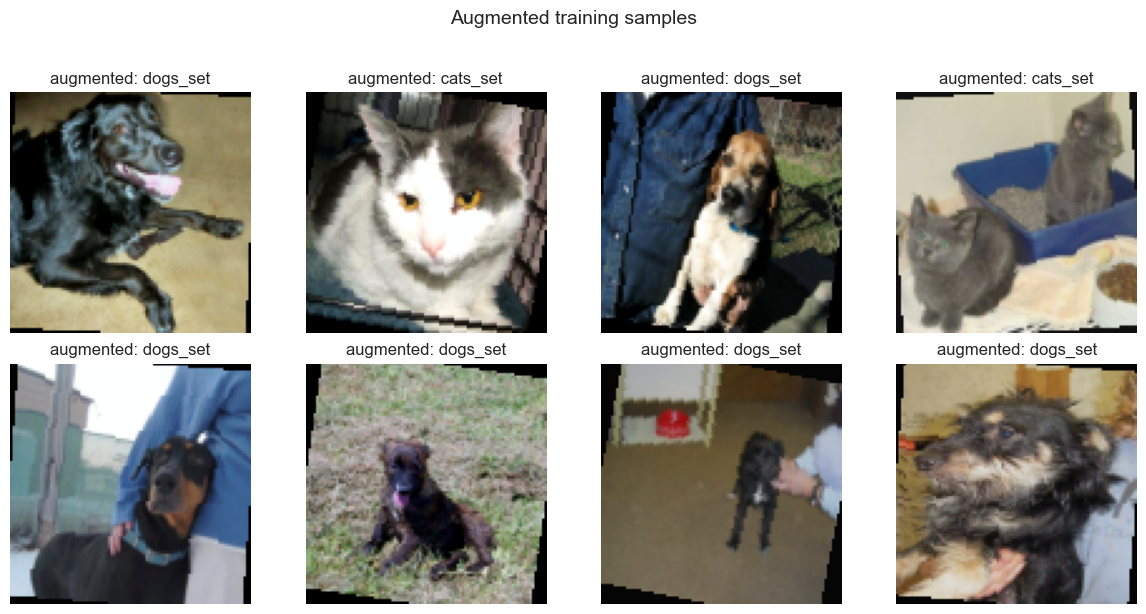

In [4]:
# Egitim verisindeki augmentation etkisini gorebilmek icin ayni goruntuyu farkli okumalarla gosteriyoruz.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.ravel(), train_idx[:8]):
    image, label = train_dataset[idx]
    image = np.transpose(image.numpy(), (1, 2, 0))
    image = np.clip(image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    ax.imshow(image)
    ax.set_title(f"augmented: {class_names[label]}")
    ax.axis("off")
plt.suptitle("Augmented training samples", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

def make_loader(dataset, split_indices, shuffle):
    return DataLoader(
        Subset(dataset, split_indices),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

In [9]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = CatDogCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_targets = []
    all_predictions = []

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, targets)

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        total_correct += (predictions == targets).sum().item()
        total_samples += targets.size(0)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    return total_loss / total_samples, total_correct / total_samples, np.array(all_targets), np.array(all_predictions)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, 30 + 1):
    train_loss, train_acc, _, _ = run_epoch(model, train_loader, optimizer)
    val_loss, val_acc, _, _ = run_epoch(model, val_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss={train_loss:.4f}, train acc={train_acc:.4f} | "
        f"val loss={val_loss:.4f}, val acc={val_acc:.4f}"
    )

Epoch 01/8 | train loss=0.6772, train acc=0.5550 | val loss=0.6887, val acc=0.5300
Epoch 02/8 | train loss=0.6771, train acc=0.5787 | val loss=0.6645, val acc=0.5600
Epoch 03/8 | train loss=0.6806, train acc=0.5825 | val loss=0.6478, val acc=0.6000
Epoch 04/8 | train loss=0.6679, train acc=0.5650 | val loss=0.6298, val acc=0.6800
Epoch 05/8 | train loss=0.6574, train acc=0.6112 | val loss=0.6141, val acc=0.6800
Epoch 06/8 | train loss=0.6575, train acc=0.6050 | val loss=0.6052, val acc=0.6500
Epoch 07/8 | train loss=0.6524, train acc=0.5988 | val loss=0.5917, val acc=0.7000
Epoch 08/8 | train loss=0.6456, train acc=0.6150 | val loss=0.6006, val acc=0.6900
Epoch 09/8 | train loss=0.6516, train acc=0.5962 | val loss=0.6251, val acc=0.6200
Epoch 10/8 | train loss=0.6450, train acc=0.6400 | val loss=0.5920, val acc=0.6900
Epoch 11/8 | train loss=0.6395, train acc=0.6275 | val loss=0.5888, val acc=0.6600
Epoch 12/8 | train loss=0.6464, train acc=0.6100 | val loss=0.5949, val acc=0.7000
Epoc

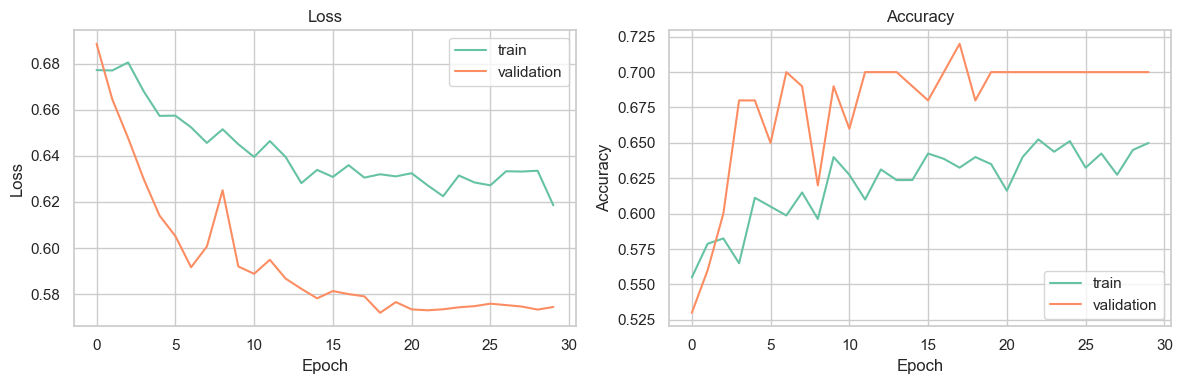

Test loss: 0.6171
Test accuracy: 0.6300

Classification report:
              precision    recall  f1-score   support

    cats_set       0.60      0.80      0.68        50
    dogs_set       0.70      0.46      0.55        50

    accuracy                           0.63       100
   macro avg       0.65      0.63      0.62       100
weighted avg       0.65      0.63      0.62       100



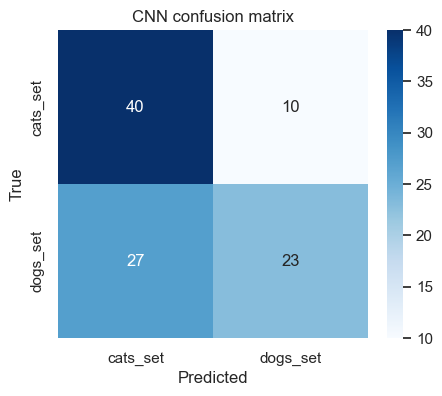

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

test_loss, test_acc, y_true, y_pred = run_epoch(model, test_loader)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("CNN confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.show()

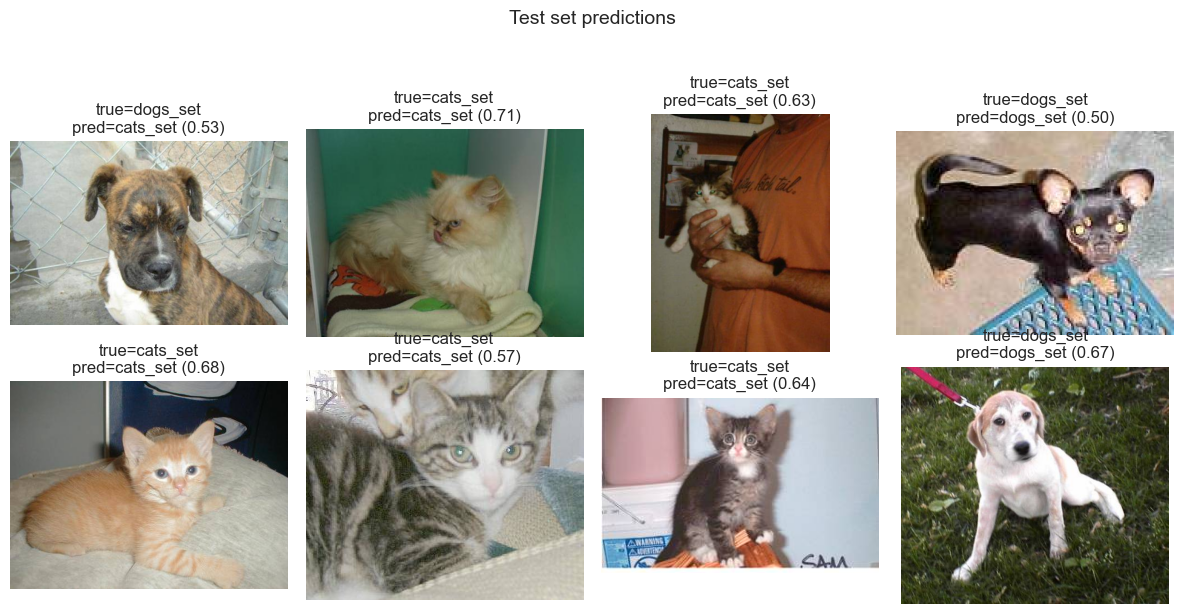

In [13]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()

    predicted_index = int(probabilities.argmax())
    return class_names[predicted_index], probabilities, image

test_paths = [base_dataset.samples[idx][0] for idx in test_idx[20:28]]
sample_lookup = {path: class_names[label] for path, label in base_dataset.samples}
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image_path in zip(axes.ravel(), test_paths):
    predicted_label, probabilities, image = predict_image(image_path)
    true_label = sample_lookup[image_path]
    ax.imshow(image)
    ax.set_title(f"true={true_label}\npred={predicted_label} ({probabilities.max():.2f})")
    ax.axis("off")
plt.suptitle("Test set predictions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()